# Figure: Tissue-specific pathway retention (engine-native)

This notebook regenerates the tissue-specific pathway-retention heatmap directly
from `ExposoGraph.engine.GraphEngine`, using the domain-specific getters added to
the engine (`get_tissues`, `get_carcinogen_groups`, `carcinogens_by_group`) instead
of a hand-maintained tissue list / carcinogen-class mapping. It's a tighter,
graph-native companion to `Figure-2-tissue-specific-pathway-retention.ipynb`,
**not** a drop-in replacement that reproduces identical numbers -- see the
"How this compares to Figure 2" section below for the methodological differences
and why they change the resulting values.

## How this compares to `Figure-2-tissue-specific-pathway-retention.ipynb`

Several deliberate changes from the original notebook, worth reviewing before
treating this as a manuscript-ready replacement:

1. **Retention rule is now "any" instead of "all".** The original notebook
   retained an edge only if *every* Enzyme/Gene endpoint cleared the expression
   threshold (logical AND across endpoints). Here, per the requested
   specification, an edge is retained if *at least one* endpoint is an Enzyme
   node clearing the threshold (logical OR / "any"). This is a substantive
   redefinition, not a re-implementation of the same statistic -- it will
   generally push retention percentages *up* relative to the old notebook,
   especially for edges with two Enzyme-like endpoints.
2. **Threshold units changed from raw nTPM to normalized `tissue_weights`.**
   The original notebook thresholded *raw* nTPM expression (`get_tissue_expression`,
   default cutoff `0.25`). This notebook thresholds the engine's own
   `tissue_weights` attribute, which `GraphEngine._apply_tissue_expression`
   computes by dividing each enzyme's raw nTPM by its own single highest-nTPM
   tissue -- so it's a *per-gene-relative* 0-1 scale ("how much of this gene's
   peak expression happens in this tissue"), not an absolute expression level.
   A raw-nTPM threshold of `0.25` and a normalized-weight threshold of the same
   number are **not comparable** -- `TISSUE_WEIGHT_THRESHOLD` below defaults to
   `0.5` on the normalized scale and should be sanity-checked/tuned rather than
   assumed equivalent to the old cutoff.
3. **Categories are now graph-native `group` labels, not manuscript classes.**
   The original notebook used 16 hand-curated "manuscript classes" (e.g.
   `"Dioxins/PCBs"`, `"Heavy metals"`) each mapped to an explicit list of
   carcinogen IDs. This notebook uses whatever `group` values actually exist on
   `Carcinogen` nodes in the loaded graph (`engine.get_carcinogen_groups()`,
   currently 21 values) with zero hardcoded chemical-to-class mapping. This is
   more automatically-correct as the graph evolves, but it's a *different,
   finer-grained* partition -- e.g. the old merged `"Dioxins/PCBs"` class is now
   two separate categories (`"Dioxin"`, `"PCB"`), and several new categories
   (`PFAS`, `Androgen`, `Alkylating`, `Ionizing_Radiation`, `Estrogen`, ...) have
   no equivalent row in the old notebook at all.
4. **Denominator uses each edge's own `carcinogen` field, not source/target ids.**
   An edge counts toward a category's denominator only if `edge["carcinogen"]`
   is itself a `Carcinogen`-typed node in that group -- matching the convention
   already established in `GraphEngine._apply_interaction_parameters`. One
   consequence: edges with no `carcinogen` context at all (many `TRANSPORTS`,
   `REPAIRS`, `PATHWAY` edges) are correctly excluded from every category, and
   edges whose `carcinogen` points at a bare `Substrate` identity node (not a
   classified `Carcinogen`) -- e.g. most of the `phase2_conjugation` /
   `competitive_inhibition` enzyme-substrate topology edges -- never contribute
   to *any* category's ratio, since `Substrate` isn't a carcinogen classification.
5. **Tissue panel is read from the graph, not hardcoded.** The original notebook
   hardcoded 8 tissues. `engine.get_tissues()` currently returns 10 (the same 8
   plus `Skin_NotSunExposed`/`Skin_SunExposed`), and will pick up any future
   change to the bundled tissue-expression panel automatically.

None of the above is "wrong" -- it's what was specified -- but flagging it here so
the two notebooks' numbers aren't mistaken for the same statistic.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make the notebook robust whether it is launched from the repo root or from Figures_Notebook/.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ExposoGraph").is_dir() and (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the ExposoGraph repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ExposoGraph.engine import GraphEngine

print(f"Repository root: {REPO_ROOT}")

Repository root: /home/user/workspace/ExposoGraph2


## 1. Instantiate the knowledge graph via `engine.py`

Uses `GraphEngine.load_reference_graph()` directly -- the same canonical loading
path (bundled `graph-data.json` + tissue expression + interaction parameters)
that the rest of the package relies on.

In [2]:
engine = GraphEngine()
load_warnings = engine.load_reference_graph()

print(f"Reference graph: {engine.node_count} nodes / {engine.edge_count} edges")
if load_warnings:
    print(f"\n{len(load_warnings)} load warning(s):")
    for warning in load_warnings:
        print(f"  - {warning}")

Reference graph: 325 nodes / 530 edges

1 load warning(s):
  - No tissue expression data for enzyme: GSTT1


## 2. Tissues, alphanumeric order

Pulled from the graph itself via `engine.get_tissues()` -- no hardcoded tissue
list -- which is already returned sorted.

In [3]:
TISSUES = engine.get_tissues()
print(f"{len(TISSUES)} tissues:")
TISSUES

10 tissues:


['Bladder',
 'Breast',
 'Colon',
 'Esophagus',
 'Kidney',
 'Liver',
 'Lung',
 'Prostate',
 'Skin_NotSunExposed',
 'Skin_SunExposed']

## 3. Carcinogen categories, alphabetical order

Pulled via `engine.get_carcinogen_groups()`: every distinct `group` label among
`Carcinogen` nodes specifically (already alphabetically sorted).

In [4]:
CARCINOGEN_CATEGORIES = engine.get_carcinogen_groups()
print(f"{len(CARCINOGEN_CATEGORIES)} carcinogen categories:")
CARCINOGEN_CATEGORIES

21 carcinogen categories:


['Alcohol',
 'Aldehyde',
 'Alkylating',
 'Androgen',
 'Aromatic_Amine',
 'Benzene',
 'Chlorinated_Solvent',
 'Dioxin',
 'Estrogen',
 'HCA',
 'Heavy_Metal',
 'Ionizing_Radiation',
 'Mycotoxin',
 'Nitrosamine',
 'Organochlorine',
 'PAH',
 'PCB',
 'PFAS',
 'Plant_Alkaloid',
 'UV_Radiation',
 'Vinyl Chloride']

## 4. Retention ratio

For each (carcinogen category, tissue) cell:

- **Denominator** -- the number of graph edges whose `carcinogen` field names a
  `Carcinogen` node in that category (see point 4 in the comparison above).
- **Numerator** -- the subset of those edges where at least one endpoint
  (source or target) is an `Enzyme` node with
  `tissue_weights[tissue] >= TISSUE_WEIGHT_THRESHOLD`.
- **Cell value** = `100 * numerator / denominator`, or `NaN` (shown as `n/a`) if
  the category has zero edges in the graph at all.

`TISSUE_WEIGHT_THRESHOLD` is on the engine's normalized 0-1 `tissue_weights`
scale -- see comparison point 2 above before treating this as equivalent to the
old notebook's raw-nTPM `0.25` cutoff.

In [5]:
TISSUE_WEIGHT_THRESHOLD = 0.5

node_data = dict(engine.G.nodes(data=True))
edges = [(u, v, data) for u, v, data in engine.G.edges(data=True)]

category_carcinogen_ids = {
    category: {node["id"] for node in engine.carcinogens_by_group(category)}
    for category in CARCINOGEN_CATEGORIES
}


def enzyme_meets_threshold(node_id: str, tissue: str, threshold: float) -> bool:
    data = node_data.get(node_id)
    if data is None or data.get("type") != "Enzyme":
        return False
    weights = data.get("tissue_weights")
    if not weights:
        return False
    return weights.get(tissue, float("-inf")) >= threshold


rows: list[list[float]] = []
denominators: dict[str, int] = {}

for category in CARCINOGEN_CATEGORIES:
    carcinogen_ids = category_carcinogen_ids[category]
    category_edges = [
        (u, v, data) for u, v, data in edges if data.get("carcinogen") in carcinogen_ids
    ]
    denominators[category] = len(category_edges)

    row: list[float] = []
    for tissue in TISSUES:
        if not category_edges:
            row.append(np.nan)
            continue
        numerator = sum(
            1
            for u, v, _data in category_edges
            if enzyme_meets_threshold(u, tissue, TISSUE_WEIGHT_THRESHOLD)
            or enzyme_meets_threshold(v, tissue, TISSUE_WEIGHT_THRESHOLD)
        )
        row.append(100.0 * numerator / len(category_edges))
    rows.append(row)

retention = pd.DataFrame(rows, index=CARCINOGEN_CATEGORIES, columns=TISSUES)

print("Category edge counts (denominator):")
for category in CARCINOGEN_CATEGORIES:
    print(f"  {category:20s} {denominators[category]:3d}")

empty_categories = [c for c, n in denominators.items() if n == 0]
print("\nCategories with zero graph edges (rendered as n/a):", empty_categories or "none")

retention

Category edge counts (denominator):
  Alcohol                9
  Aldehyde              30
  Alkylating            39
  Androgen               2
  Aromatic_Amine        10
  Benzene                6
  Chlorinated_Solvent   13
  Dioxin                10
  Estrogen               2
  HCA                   11
  Heavy_Metal           77
  Ionizing_Radiation    13
  Mycotoxin              6
  Nitrosamine           23
  Organochlorine        15
  PAH                   37
  PCB                    7
  PFAS                   6
  Plant_Alkaloid         3
  UV_Radiation           7
  Vinyl Chloride         4

Categories with zero graph edges (rendered as n/a): none


,Bladder,Breast,Colon,Esophagus,Kidney,Liver,Lung,Prostate,Skin_NotSunExposed,Skin_SunExposed
Alcohol,0.000000,0.000000,0.000000,0.000000,0.000000,22.222222,0.000000,0.000000,0.000000,0.000000
Aldehyde,16.666667,20.000000,16.666667,20.000000,16.666667,33.333333,10.000000,16.666667,13.333333,13.333333
Alkylating,5.128205,5.128205,5.128205,17.948718,5.128205,15.384615,5.128205,5.128205,5.128205,5.128205
Androgen,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,50.000000,0.000000,0.000000
Aromatic_Amine,0.000000,10.000000,0.000000,0.000000,10.000000,60.000000,10.000000,10.000000,0.000000,0.000000
Benzene,0.000000,0.000000,0.000000,33.333333,16.666667,33.333333,16.666667,0.000000,0.000000,0.000000
Chlorinated_Solvent,7.692308,0.000000,0.000000,0.000000,7.692308,23.076923,0.000000,7.692308,0.000000,0.000000
Dioxin,80.000000,80.000000,30.000000,30.000000,30.000000,80.000000,80.000000,30.000000,80.000000,80.000000
Estrogen,0.000000,50.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000
HCA,0.000000,0.000000,0.000000,0.000000,0.000000,72.727273,0.000000,0.000000,0.000000,0.000000


## 5. Heatmap

Seaborn heatmap with a blue/red diverging colormap (`RdBu_r`: low retention ->
blue, high retention -> red), centered at 50%. Categories with no graph edges at
all are masked and annotated `n/a`. Not saved to disk -- rendered inline only.

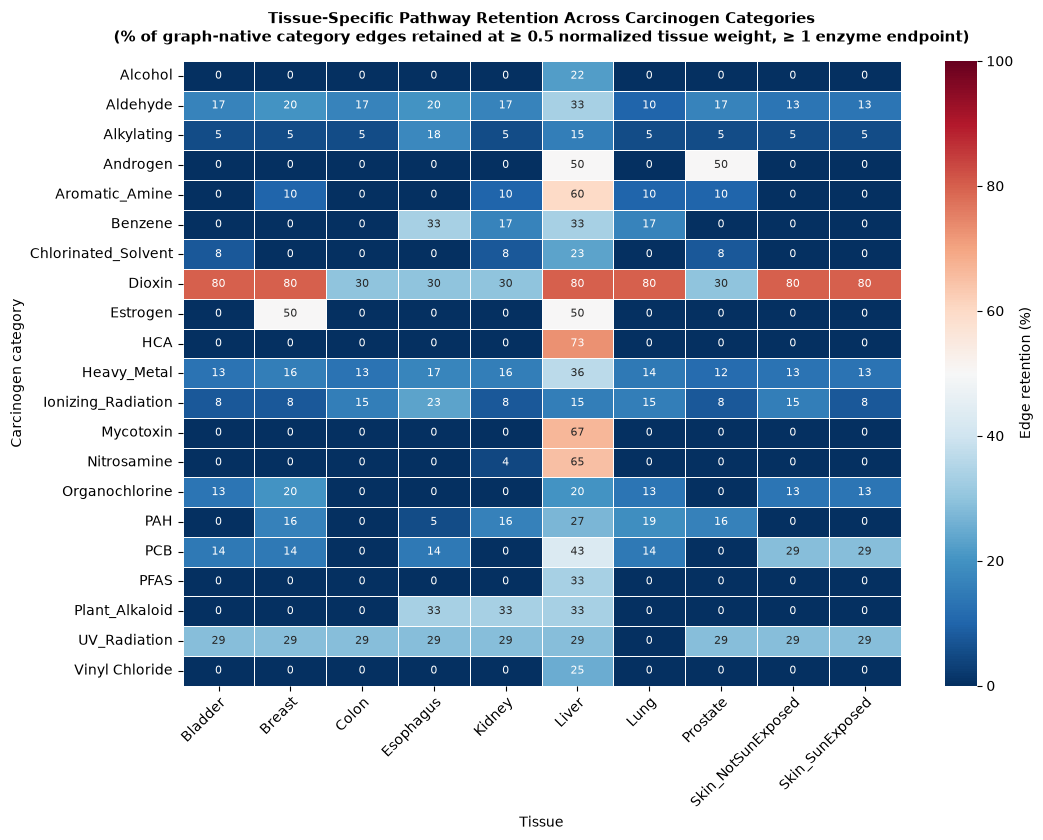

In [6]:
fig, ax = plt.subplots(figsize=(11, 8.5))

mask = retention.isna()
sns.heatmap(
    retention,
    ax=ax,
    cmap="RdBu_r",
    vmin=0,
    vmax=100,
    center=50,
    mask=mask,
    annot=True,
    fmt=".0f",
    annot_kws={"fontsize": 8},
    linewidths=0.5,
    linecolor="white",
    square=False,
    cbar_kws={"label": "Edge retention (%)"},
)
ax.set_facecolor("#e8e8e8")

for row_idx, category in enumerate(CARCINOGEN_CATEGORIES):
    if denominators[category] == 0:
        for col_idx in range(len(TISSUES)):
            ax.text(
                col_idx + 0.5,
                row_idx + 0.5,
                "n/a",
                ha="center",
                va="center",
                fontsize=8,
                color="#666666",
            )

ax.set_xlabel("Tissue")
ax.set_ylabel("Carcinogen category")
ax.set_title(
    "Tissue-Specific Pathway Retention Across Carcinogen Categories\n"
    f"(% of graph-native category edges retained at \u2265 {TISSUE_WEIGHT_THRESHOLD:g} "
    "normalized tissue weight, \u2265 1 enzyme endpoint)",
    fontsize=11,
    weight="bold",
    pad=14,
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

fig.tight_layout()
plt.show()